In [1]:
#Copyright 2026 Mücahit Sahin
#
#Licensed under the Apache License, Version 2.0 (the "License");
#you may not use this file except in compliance with the License.
#You may obtain a copy of the License at
#
#    http://www.apache.org/licenses/LICENSE-2.0
#
#Unless required by applicable law or agreed to in writing, software
#distributed under the License is distributed on an "AS IS" BASIS,
#WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
#See the License for the specific language governing permissions and
#limitations under the License.

In [2]:
import os
import re
import shutil
import numpy as np
import pandas as pd
import json
import tiktoken
pd.set_option('display.max_colwidth', None)

import plotly.express as px
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler, normalize
from sklearn.model_selection import ParameterGrid
from sklearn.decomposition import PCA
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from xgboost import XGBClassifier
from autogluon.tabular import TabularPredictor


from utils import hf_model
from utils import gpt
from utils import splitting
from utils import metrics
from utils import feature_generator
from utils import feature_extraction

# disable warnings
import warnings
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    module="xgboost"
)

/opt/anaconda/envs/test/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator CountVectorizer from version 0.22.2.post1 when using version 1.4.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [3]:
all_datasets = pd.read_csv("data/Benchmark-Labeled-Data/all_data.csv")
all_datasets.Attribute_name = all_datasets.Attribute_name.astype('str') # NaNs
all_datasets.head()

,Record_id,Attribute_name,y_act,total_vals,num_nans,%_nans,num_of_dist_val,%_dist_val,mean,std_dev,...,mean_stopword_total,stdev_stopword_total,mean_char_count,stdev_char_count,mean_whitespace_count,stdev_whitespace_count,mean_delim_count,stdev_delim_count,is_list,is_long_sentence
0,33,Area,categorical,21477,0,0.0,174,0.810169,0.000000,0.000000,...,0.2,0.4,10.0,4.816638,0.4,0.8,0.4,0.8,False,False
1,33,Area Code,categorical,21477,0,0.0,174,0.810169,125.449411,72.866452,...,0.0,0.0,1.0,0.000000,0.0,0.0,0.0,0.0,False,False
2,33,Element,categorical,21477,0,0.0,2,0.009312,0.000000,0.000000,...,0.0,0.0,4.0,0.000000,0.0,0.0,0.0,0.0,False,False
3,33,Element Code,categorical,21477,0,0.0,2,0.009312,5211.687154,146.816661,...,0.0,0.0,4.0,0.000000,0.0,0.0,0.0,0.0,False,False
4,33,Item,categorical,21477,0,0.0,115,0.535457,0.000000,0.000000,...,0.8,0.4,19.6,2.244994,2.0,0.0,2.0,0.0,False,False


In [4]:
featurized_data = pd.read_csv('results/featurized_data_with_llm_features.csv')

In [5]:
featurized_data.insert(0, 'Attribute_name', all_datasets['Attribute_name'])
featurized_data.insert(1, 'y_act', all_datasets['y_act'])

In [6]:
featurized_data.head()

,Attribute_name,y_act,total_vals,num_nans,%_nans,num_of_dist_val,%_dist_val,mean,std_dev,min_val,...,Qwen_3_5_detect_all_at_once_fewshot,Qwen_3_5_is_numeric_fewshot,Qwen_3_5_is_categorical_fewshot,Qwen_3_5_is_datetime_fewshot,Qwen_3_5_is_sentence_fewshot,Qwen_3_5_is_url_fewshot,Qwen_3_5_is_embedded_number_fewshot,Qwen_3_5_is_list_fewshot,Qwen_3_5_is_not_generalizable_fewshot,Qwen_3_5_is_context_specific_fewshot
0,Area,categorical,21477,0,0.0,174,0.810169,0.000000,0.000000,0.0,...,categorical,0,1,0,0,0,0,0,0,0
1,Area Code,categorical,21477,0,0.0,174,0.810169,125.449411,72.866452,1.0,...,categorical,0,1,0,0,0,0,0,0,1
2,Element,categorical,21477,0,0.0,2,0.009312,0.000000,0.000000,0.0,...,categorical,0,1,0,0,0,0,0,0,0
3,Element Code,categorical,21477,0,0.0,2,0.009312,5211.687154,146.816661,5142.0,...,not-generalizable,0,1,0,0,0,0,0,1,1
4,Item,categorical,21477,0,0.0,115,0.535457,0.000000,0.000000,0.0,...,categorical,0,1,0,0,0,0,0,0,0


In [7]:
class_map = {
    0: 'numeric',
    1: 'categorical',
    2: 'datetime',
    3: 'sentence',
    4: 'url',
    5: 'embedded-number',
    6: 'list',
    7: 'not-generalizable',
    8: 'context-specific'
}

# Build the Hybrid System

In [8]:
##### AutoGluon #####

def resample_and_evaluate(n_splits, feature_sets, featurized_data, raw_data):
    # Create a list to store the results for each feature set on each test set
    results = []
    results_df = pd.DataFrame()
    save_path = ""
    model_names = {
        'RF': 'RandomForest',
        'XGB': 'XGBoost',
        'CAT': 'CatBoost',
        'GBM': 'LightGBM',
        'NN_TORCH': 'NeuralNetTorch',
        'FASTAI': 'NeuralNetFastAI',
        'XT': 'ExtraTrees',
        'KNN': 'KNeighbors',
        'LR': 'LinearModel',
    }
    
    
    # limit to 100 resamples at max
    if n_splits > 100:
        n_splits = 100
    
    with open('seeds.txt', 'r') as fp: # change the tolerance here
        seeds = fp.read().splitlines()
        seeds = [int(i) for i in seeds] # convert back to int
        fp.close()

    
    save_path = "results/Autogluon_results_on_" + str(n_splits) + "_resamples.csv"
    feature_sets_copy = feature_sets.copy()
    
    
    if os.path.isfile(save_path):
        df = pd.read_csv(save_path)
        results = df.to_dict()
        done_feature_sets = np.unique(list(results['Feature Set'].values()))
        for fs in done_feature_sets:
            if fs in feature_sets_copy.keys():
                del feature_sets_copy[fs]
        results = list(df.T.to_dict().values()) # convert back to list of dicts to match original format

        # already exists and all features done
        if feature_sets_copy == {}:
            return pd.read_csv(save_path)
    
    
    # Iterate over each feature set and its associated features    
    for feature_set in feature_sets_copy:
        print(f"Doing feature set '{feature_set}':\n")
        features_to_learn = feature_sets[feature_set]['features']
        feature_set_data = featurized_data.copy()
        llms = ('gpt_5_4', 'qwen_3_5', 'gemma_4')
        llm_cols = [fl for fl in features_to_learn if fl.lower().startswith(llms)]
        boolean_cols = ['has_delimiters', 'has_url', 'has_email', 'has_date', 'is_list', 'is_long_sentence']


        print(f"\tModel configuration:")

        # Gather all settings
        config = {
            'model': model_names.get(feature_sets[feature_set].get('model'), '-') if feature_sets[feature_set].get('model') else '-',
            'vectorizer.type': feature_sets[feature_set].get('vectorizer', {}).get('type', '-') if feature_sets[feature_set].get('vectorizer') else '-',
            'vectorizer.normalize': feature_sets[feature_set].get('vectorizer', {}).get('normalize', '-') if feature_sets[feature_set].get('vectorizer') else '-',
            'embedding': feature_sets[feature_set].get('embedding', '-')
        }
        
        # Print everything
        for key, val in config.items():
            print(f"\t\t{key:<20} :\t{val}")
        
        print('\n')
        

        # Some error checks
        if feature_sets[feature_set].get('model') == None:
            print(f"\t{'#' * 39} ERROR {'#' * 39}\n\n" + \
                  f"\t--> Please specifiy an Autogluon model" + \
                  f" in the feature set at key 'model'.\n" + \
                  f"\t--> Possible model names are: {list(model_names.keys())}.\n"
            )
            return
            

        # Transformer/LLM embeddings for feature names
        if feature_sets[feature_set].get('embedding') == 'bert':
            bert_vc = feature_extraction.BERTVectorizer()
            feature_set_data = bert_vc.transform(featurized_data)
            features_to_learn = features_to_learn + ['BERT_embedding_dim_'+ str(i) for i in range(768)]
            
        if feature_sets[feature_set].get('embedding') == 'all-minilm-l6-v2':
            sentenceTF_vc = feature_extraction.SentenceTFVectorizer()
            feature_set_data = sentenceTF_vc.transform(featurized_data)
            features_to_learn = features_to_learn + ['SentenceTF_embedding_dim_'+ str(i) for i in range(384)]
            
        if feature_sets[feature_set].get('embedding') == 'fasttext':
            fasttext_vc = feature_extraction.FastTextVectorizer()
            feature_set_data = fasttext_vc.transform(featurized_data)
            features_to_learn = features_to_learn + ['FastText_embedding_dim_'+ str(i) for i in range(300)]

        
        # create the number of resample splits
        for i in range(n_splits):
            print(f"\tResample {i+1} ... ", end="")
            

            seed = seeds[i]
            best_inner_model_save_path = 'results/Models/' + str(seed) + '/Inner_Loop/' + \
                                         feature_set.replace('+', '')
            best_inner_model_save_path = ' '.join(best_inner_model_save_path.split()).replace(' ', '_')
            
            best_outer_model_save_path = 'results/Models/' + str(seed) + '/Outer_Loop/' + \
                                         feature_set.replace('+', '')
            best_outer_model_save_path = ' '.join(best_outer_model_save_path.split()).replace(' ', '_')
            
            metric = {
                'Feature Set': feature_set,
                'Model': None,
                'Seed': seed,
                'F1-Score (Dev)': 0,
                'Precision (Dev)': 0,
                'Recall (Dev)': 0,
                'Accuracy (Dev)': 0,
                'F1-Score (Test)': 0,
                'Precision (Test)': 0,
                'Recall (Test)': 0,
                'Accuracy (Test)': 0,
                'class_numeric_F1-Score': 0,
                'class_numeric_Precision': 0,
                'class_numeric_Recall': 0,
                'class_numeric_Accuracy': 0,
                'class_categorical_F1-Score': 0,
                'class_categorical_Precision': 0,
                'class_categorical_Recall': 0,
                'class_categorical_Accuracy': 0,
                'class_sentence_F1-Score': 0,
                'class_sentence_Precision': 0,
                'class_sentence_Recall': 0,
                'class_sentence_Accuracy': 0,
                'class_url_F1-Score': 0,
                'class_url_Precision': 0,
                'class_url_Recall': 0,
                'class_url_Accuracy': 0,
                'class_list_F1-Score': 0,
                'class_list_Precision': 0,
                'class_list_Recall': 0,
                'class_list_Accuracy': 0,
                'class_embedded-number_F1-Score': 0,
                'class_embedded-number_Precision': 0,
                'class_embedded-number_Recall': 0,
                'class_embedded-number_Accuracy': 0,
                'class_datetime_F1-Score': 0,
                'class_datetime_Precision': 0,
                'class_datetime_Recall': 0,
                'class_datetime_Accuracy': 0,
                'class_not-generalizable_F1-Score': 0,
                'class_not-generalizable_Precision': 0,
                'class_not-generalizable_Recall': 0,
                'class_not-generalizable_Accuracy': 0,
                'class_context-specific_F1-Score': 0,
                'class_context-specific_Precision': 0,
                'class_context-specific_Recall': 0,
                'class_context-specific_Accuracy': 0
            }
            
            best_model = {
                'Name': None,
                'Parameters': None,
                'F1-Score (Dev)': 0,
                'Precision (Dev)': 0,
                'Recall (Dev)': 0,
                'Accuracy (Dev)': 0,
                'F1-Score (Test)': 0,
                'Precision (Test)': 0,
                'Recall (Test)': 0,
                'Accuracy (Test)': 0
            }


            outer_fold = splitting.create_split(raw_data, test_size=0.2, target_col='y_act', group_col='Record_id', random_state=seed)
            train = raw_data.iloc[outer_fold["train"]].reset_index(drop=True)
            train_featurized = feature_set_data.iloc[outer_fold["train"]].reset_index(drop=True)
            test_featurized = feature_set_data.iloc[outer_fold["test"]].reset_index(drop=True)
            
            inner_fold = splitting.create_split(train, test_size=0.25, target_col='y_act', group_col='Record_id', random_state=seed)
            inner_train_featurized = train_featurized.iloc[inner_fold["train"]].reset_index(drop=True)
            dev_featurized = train_featurized.iloc[inner_fold["test"]].reset_index(drop=True)

            
            if feature_set == "GPT-5.4 Direct Classification" or \
                feature_set == "GPT-5.4 Direct Classification (Few-shot)" or \
                feature_set == "Gemma 4 4B-it Direct Classification" or \
                feature_set == "Gemma 4 4B-it Direct Classification (Few-shot)" or \
                feature_set == "Qwen 3.5 9B Direct Classification" or \
                feature_set == "Qwen 3.5 9B Direct Classification (Few-shot)":
                y_dev = dev_featurized["y_act"]
                y_pred = dev_featurized.filter(features_to_learn)
                y_pred = [pred[0] for pred in y_pred.values]
                
                # Calculate performance
                acc_dev = accuracy_score(y_dev, y_pred)
                f1_dev = f1_score(y_dev, y_pred, average='macro')
                prec_dev = precision_score(y_dev, y_pred, average='macro')
                rec_dev = recall_score(y_dev, y_pred, average='macro')

                y_test = test_featurized["y_act"]
                y_pred = test_featurized.filter(features_to_learn)
                y_pred = [pred[0] for pred in y_pred.values]
                
                # Calculate performance
                acc_test = accuracy_score(y_test, y_pred)
                f1_test = f1_score(y_test, y_pred, average='macro')
                prec_test = precision_score(y_test, y_pred, average='macro')
                rec_test = recall_score(y_test, y_pred, average='macro')

                metric["F1-Score (Dev)"] = f1_dev
                metric["Precision (Dev)"] = prec_dev
                metric["Recall (Dev)"] = rec_dev
                metric["Accuracy (Dev)"] = acc_dev

                metric["F1-Score (Test)"] = f1_test
                metric["Precision (Test)"] = prec_test
                metric["Recall (Test)"] = rec_test
                metric["Accuracy (Test)"] = acc_test

                
                binary_metrics = metrics.binary_metrics(le.inverse_transform(y_test),
                                                        le.inverse_transform(y_pred),
                                                        class_map,
                                                        return_results=True)

                for c in binary_metrics:
                    for m in binary_metrics[c]:
                        metric["class_" + c + "_" + m] = binary_metrics[c][m]
    
                results.append(metric)
                print("Done!\n")
                
            else:
                if feature_sets[feature_set].get('vectorizer'):
                    if feature_sets[feature_set]['vectorizer'].get('type') == 'bigram':
                        bigram_vc_inner_loop = feature_extraction.BigramVectorizer()
                        if feature_sets[feature_set]['vectorizer'].get('normalize'):
                            bigram_vc_inner_loop.fit(inner_train_featurized, normalize=True)
                        else:
                            bigram_vc_inner_loop.fit(inner_train_featurized, normalize=False, top_k=1500)
    
                        inner_train_featurized = bigram_vc_inner_loop.transform(inner_train_featurized.filter(feature_sets[feature_set]['features'] + ['Attribute_name', 'y_act']))
                        dev_featurized = bigram_vc_inner_loop.transform(dev_featurized.filter(feature_sets[feature_set]['features'] + ['Attribute_name', 'y_act']))
    
                        features_to_learn = feature_sets[feature_set]['features'] + [str(b) for b in list(bigram_vc_inner_loop.bigrams.values())]
                        

                # Model
                model = TabularPredictor(label="y_act",
                                         problem_type='multiclass',
                                         eval_metric='f1_macro',
                                         path=best_inner_model_save_path,
                                         verbosity=0)

                y_train = inner_train_featurized["y_act"]
                y_dev = dev_featurized["y_act"]

                   
                # Training
                X_train = inner_train_featurized.filter(features_to_learn)
                # some columns are int, make all strings to escape error from model.fit
                X_train.columns = X_train.columns.astype(str)
                train_data = X_train.copy()
                train_data["y_act"] = y_train
                
                # Predicting
                X_dev = dev_featurized.filter(features_to_learn)
                # some columns are int, make all strings to escape error from model.fit
                X_dev.columns = X_dev.columns.astype(str)
                dev_data = X_dev.copy()
                dev_data["y_act"] = y_dev

                # Model
                model.fit(
                    train_data=train_data,
                    tuning_data=dev_data,
                    use_bag_holdout=True,    # makes sure to use dev_data
                    feature_generator=None,  # disables preprocessing
                    presets='best_quality',
                    hyperparameters={
                        feature_sets[feature_set]['model']: {}
                    },
                    time_limit=600,
                    num_stack_levels=0,
                    num_bag_folds=0
                )
                
                y_pred = model.predict(dev_data)

                # Calculate performance of the model
                acc_dev = accuracy_score(y_dev, y_pred)
                f1_dev = f1_score(y_dev, y_pred, average='macro')
                prec_dev = precision_score(y_dev, y_pred, average='macro')
                rec_dev = recall_score(y_dev, y_pred, average='macro')

                best_model["Name"] = model_names.get(feature_sets[feature_set]['model'])
                best_model["Parameters"] = model._trainer.load_model(model.leaderboard(silent=True).iloc[0]['model']).params
                best_model["F1-Score (Dev)"] = f1_dev
                best_model["Precision (Dev)"] = prec_dev
                best_model["Recall (Dev)"] = rec_dev
                best_model["Accuracy (Dev)"] = acc_dev

                metric["F1-Score (Dev)"] = f1_dev
                metric["Precision (Dev)"] = prec_dev
                metric["Recall (Dev)"] = rec_dev
                metric["Accuracy (Dev)"] = acc_dev
                
            
            if feature_sets[feature_set].get('vectorizer'):
                if feature_sets[feature_set]['vectorizer'].get('type') == 'bigram':
                    bigram_vc_outer_loop = feature_extraction.BigramVectorizer()
                    if feature_sets[feature_set]['vectorizer'].get('normalize'):
                        bigram_vc_outer_loop.fit(train_featurized, normalize=True)
                    else:
                        bigram_vc_outer_loop.fit(train_featurized, normalize=False, top_k=1500)

                    train_featurized = bigram_vc_outer_loop.transform(train_featurized.filter(feature_sets[feature_set]['features'] + ['Attribute_name', 'y_act']))
                    test_featurized = bigram_vc_outer_loop.transform(test_featurized.filter(feature_sets[feature_set]['features'] + ['Attribute_name', 'y_act']))
                    
                    features_to_learn = feature_sets[feature_set]['features'] + [str(b) for b in list(bigram_vc_outer_loop.bigrams.values())]

                
            # Best Tuned Model
            tuned_model = TabularPredictor(label="y_act",
                                     problem_type='multiclass',
                                     eval_metric='f1_macro',
                                     path=best_outer_model_save_path,
                                     verbosity=0)
            
            y_train = train_featurized["y_act"]
            y_test = test_featurized["y_act"]
                
            # Training
            X_train = train_featurized.filter(features_to_learn)
            # some columns are int, make all strings to escape error from model.fit
            X_train.columns = X_train.columns.astype(str)
            train_data = X_train.copy()
            train_data["y_act"] = y_train
            
            # Predicting
            X_test = test_featurized.filter(features_to_learn)
            # some columns are int, make all strings to escape error from model.fit
            X_test.columns = X_test.columns.astype(str)
            test_data = X_test.copy()
            test_data["y_act"] = y_test


            # Model
            tuned_model.fit(
                train_data=train_data,
                feature_generator=None,  # disables preprocessing
                hyperparameters={feature_sets[feature_set]['model']: best_model["Parameters"]},
                excluded_model_types=[],  # ensures no other models are trained
                presets='best_quality',
                time_limit=600,
                num_stack_levels=0,
                num_bag_folds=0
            )

            y_pred = tuned_model.predict(test_data)

            # Calculate performance from best model
            acc_test = accuracy_score(y_test, y_pred)
            f1_test = f1_score(y_test, y_pred, average='macro')
            prec_test = precision_score(y_test, y_pred, average='macro')
            rec_test = recall_score(y_test, y_pred, average='macro')

            best_model["F1-Score (Test)"] = f1_test
            best_model["Precision (Test)"] = prec_test
            best_model["Recall (Test)"] = rec_test
            best_model["Accuracy (Test)"] = acc_test

            metric["Seed"] = seed
            metric["Model"] = {'Name': best_model['Name'], 'Parameters': best_model['Parameters']}
            metric["F1-Score (Test)"] = f1_test
            metric["Precision (Test)"] = prec_test
            metric["Recall (Test)"] = rec_test
            metric["Accuracy (Test)"] = acc_test

            binary_metrics = metrics.binary_metrics(le.inverse_transform(y_test),
                                                    le.inverse_transform(y_pred),
                                                    class_map,
                                                    return_results=True)

            for c in binary_metrics:
                for m in binary_metrics[c]:
                    metric["class_" + c + "_" + m] = binary_metrics[c][m]
            
            results.append(metric)
            print("Done!\n")

        # intermediate save
        results_df = pd.DataFrame(results)
        results_df.to_csv(save_path, index=False)
            
    return results_df

# Label encoder for LLM Classification Feature column

In [9]:
le = LabelEncoder()

featurized_data['y_act'] = le.fit_transform(featurized_data['y_act'])

featurized_data['GPT_5_4_detect_all_at_once'] = le.transform(featurized_data['GPT_5_4_detect_all_at_once'])
featurized_data['GPT_5_4_detect_all_at_once_fewshot'] = le.transform(featurized_data['GPT_5_4_detect_all_at_once_fewshot'])
featurized_data['Qwen_3_5_detect_all_at_once'] = le.transform(featurized_data['Qwen_3_5_detect_all_at_once'])
featurized_data['Qwen_3_5_detect_all_at_once_fewshot'] = le.transform(featurized_data['Qwen_3_5_detect_all_at_once_fewshot'])
featurized_data['Gemma_4_detect_all_at_once'] = le.transform(featurized_data['Gemma_4_detect_all_at_once'])
featurized_data['Gemma_4_detect_all_at_once_fewshot'] = le.transform(featurized_data['Gemma_4_detect_all_at_once_fewshot'])

In [10]:
for i, class_label in enumerate(le.classes_):
    print(f"{class_label:<18} --> {i:>3}")

categorical        -->   0
context-specific   -->   1
datetime           -->   2
embedded-number    -->   3
list               -->   4
not-generalizable  -->   5
numeric            -->   6
sentence           -->   7
url                -->   8


# LLM Features

In [11]:
gpt_5_4_features = [f for f in list(featurized_data.columns) if "gpt_5_4" in str(f).lower() and not "all_at_once" in str(f).lower() and not "fewshot" in str(f).lower()]
gpt_5_4_classification_feature = [f for f in list(featurized_data.columns) if "gpt_5_4" in str(f).lower() and "all_at_once" in str(f).lower() and not "fewshot" in str(f).lower()]

gpt_5_4_fewshot_features = [f for f in list(featurized_data.columns) if "gpt_5_4" in str(f).lower() and "fewshot" in str(f).lower() and not "all_at_once" in str(f).lower()]
gpt_5_4_fewshot_classification_feature = [f for f in list(featurized_data.columns) if "gpt_5_4" in str(f).lower() and "fewshot" in str(f).lower() and "all_at_once" in str(f).lower()]

qwen_3_5_features = [f for f in list(featurized_data.columns) if "qwen_3_5" in str(f).lower() and not "all_at_once" in str(f).lower() and not "fewshot" in str(f).lower()]
qwen_3_5_classification_feature = [f for f in list(featurized_data.columns) if "qwen_3_5" in str(f).lower() and "all_at_once" in str(f).lower() and not "fewshot" in str(f).lower()]

qwen_3_5_fewshot_features = [f for f in list(featurized_data.columns) if "qwen_3_5" in str(f).lower() and "fewshot" in str(f).lower() and not "all_at_once" in str(f).lower()]
qwen_3_5_fewshot_classification_feature = [f for f in list(featurized_data.columns) if "qwen_3_5" in str(f).lower() and "fewshot" in str(f).lower() and "all_at_once" in str(f).lower()]

gemma_4_features = [f for f in list(featurized_data.columns) if "gemma_4" in str(f).lower() and not "all_at_once" in str(f).lower() and not "fewshot" in str(f).lower()]
gemma_4_classification_feature = [f for f in list(featurized_data.columns) if "gemma_4" in str(f).lower() and "all_at_once" in str(f).lower() and not "fewshot" in str(f).lower()]

gemma_4_fewshot_features = [f for f in list(featurized_data.columns) if "gemma_4" in str(f).lower() and "fewshot" in str(f).lower() and not "all_at_once" in str(f).lower()]
gemma_4_fewshot_classification_feature = [f for f in list(featurized_data.columns) if "gemma_4" in str(f).lower() and "fewshot" in str(f).lower() and "all_at_once" in str(f).lower()]

sortinghat_features = list(featurized_data.columns[2:1478])

base_features_with_regex = sortinghat_features[:25]
base_features = [s for s in sortinghat_features[:25] if not 'is_' in s and not 'has_' in s]

# Feature Sets

In [12]:
feature_sets = {
    
    ####################### Core #########################
    
    "Core Features": {
        'features': base_features_with_regex,
        'model': 'XGB',
    },
    "Core Features + Bi-grams": {
        'features': base_features_with_regex,
        'vectorizer': {
            'type': 'bigram',
            'normalize': False
        },
        'model': 'XGB',
    },
    "Core Features + all-MiniLM-L6-v2 embeddings": {
        'features': base_features_with_regex,
        'embedding': 'all-minilm-l6-v2',
        'model': 'XGB',
    },
    # "Core Features + BERT embeddings": {
    #     'features': base_features_with_regex,
    #     'embedding': 'bert',
    #     'model': 'XGB',
    # },
    # "Core Features + Fasttext embeddings": {
    #     'features': base_features_with_regex,
    #     'embedding': 'fasttext',
    #     'model': 'XGB',
    # },
    

    ####################### Core + LLM #########################

    #### GPT-5.4 ####
    # "Core Features + GPT-5.4 Binary Features": {
    #     'features': base_features_with_regex + gpt_5_4_features,
    #     'model': 'XGB',
    # },
    # "Core Features + GPT-5.4 Binary Features (Few-shot)": {
    #     'features': base_features_with_regex + gpt_5_4_fewshot_features,
    #     'model': 'XGB',
    # },
    # "Core Features + GPT-5.4 Multi-class Feature": {
    #     'features': base_features_with_regex + gpt_5_4_classification_feature,
    #     'model': 'XGB',
    # },
    # "Core Features + GPT-5.4 Multi-class Feature (Few-shot)": {
    #     'features': base_features_with_regex + gpt_5_4_fewshot_classification_feature,
    #     'model': 'XGB',
    # },

    # #### Qwen 3.5 ####
    # "Core Features + Qwen 3.5 Binary Features": {
    #     'features': base_features_with_regex + qwen_3_5_features,
    #     'model': 'XGB',
    # },
    # "Core Features + Qwen 3.5 Binary Features (Few-shot)": {
    #     'features': base_features_with_regex + qwen_3_5_fewshot_features,
    #     'model': 'XGB',
    # },
    # "Core Features + Qwen 3.5 Multi-class Feature": {
    #     'features': base_features_with_regex + qwen_3_5_classification_feature,
    #     'model': 'XGB',
    # },
    # "Core Features + Qwen 3.5 Multi-class Feature (Few-shot)": {
    #     'features': base_features_with_regex + qwen_3_5_fewshot_classification_feature,
    #     'model': 'XGB',
    # },

    # #### Gemma 4 ####
    # "Core Features + Gemma 4 Binary Features": {
    #     'features': base_features_with_regex + gemma_4_features,
    #     'model': 'XGB',
    # },
    # "Core Features + Gemma 4 Binary Features (Few-shot)": {
    #     'features': base_features_with_regex + gemma_4_fewshot_features,
    #     'model': 'XGB',
    # },
    # "Core Features + Gemma 4 Multi-class Feature": {
    #     'features': base_features_with_regex + gemma_4_classification_feature,
    #     'model': 'XGB',
    # },
    # "Core Features + Gemma 4 Multi-class Feature (Few-shot)": {
    #     'features': base_features_with_regex + gemma_4_fewshot_classification_feature,
    #     'model': 'XGB',
    # },

    
    ####################### Core + Bi-grams / Word emb. + LLM #########################
    
    #### GPT-5.4 ####
    # "Core Features + all-MiniLM-L6-v2 embeddings + GPT-5.4 Binary Features": {
    #     'features': base_features_with_regex + gpt_5_4_features,
    #     'embedding': 'all-minilm-l6-v2',
    #     'model': 'XGB',
    # },
    # "Core Features + Bi-grams + GPT-5.4 Binary Features": {
    #     'features': base_features_with_regex + gpt_5_4_features,
    #     'vectorizer': {
    #         'type': 'bigram',
    #         'normalize': False
    #     },
    #     'model': 'XGB',
    # },
    "Core Features + all-MiniLM-L6-v2 embeddings + GPT-5.4 Binary Features (Few-shot)": {
        'features': base_features_with_regex + gpt_5_4_fewshot_features,
        'embedding': 'all-minilm-l6-v2',
        'model': 'XGB',
    },
    "Core Features + Bi-grams + GPT-5.4 Binary Features (Few-shot)": {
        'features': base_features_with_regex + gpt_5_4_fewshot_features,
        'vectorizer': {
            'type': 'bigram',
            'normalize': False
        },
        'model': 'XGB',
    },
    # "Core Features + all-MiniLM-L6-v2 embeddings + GPT-5.4 Multi-class Feature": {
    #     'features': base_features_with_regex + gpt_5_4_classification_feature,
    #     'embedding': 'all-minilm-l6-v2',
    #     'model': 'XGB',
    # },
    # "Core Features + Bi-grams + GPT-5.4 Multi-class Feature": {
    #     'features': base_features_with_regex + gpt_5_4_classification_feature,
    #     'vectorizer': {
    #         'type': 'bigram',
    #         'normalize': False
    #     },
    #     'model': 'XGB',
    # },
    # "Core Features + all-MiniLM-L6-v2 embeddings + GPT-5.4 Multi-class Feature (Few-shot)": {
    #     'features': base_features_with_regex + gpt_5_4_fewshot_classification_feature,
    #     'embedding': 'all-minilm-l6-v2',
    #     'model': 'XGB',
    # },
    # "Core Features + Bi-grams + GPT-5.4 Multi-class Feature (Few-shot)": {
    #     'features': base_features_with_regex + gpt_5_4_fewshot_classification_feature,
    #     'vectorizer': {
    #         'type': 'bigram',
    #         'normalize': False
    #     },
    #     'model': 'XGB',
    # },

    # #### Qwen 3.5 ####
    # "Core Features + all-MiniLM-L6-v2 embeddings + Qwen 3.5 Binary Features": {
    #     'features': base_features_with_regex + qwen_3_5_features,
    #     'embedding': 'all-minilm-l6-v2',
    #     'model': 'XGB',
    # },
    # "Core Features + Bi-grams + Qwen 3.5 Binary Features": {
    #     'features': base_features_with_regex + qwen_3_5_features,
    #     'vectorizer': {
    #         'type': 'bigram',
    #         'normalize': False
    #     },
    #     'model': 'XGB',
    # },
    # "Core Features + all-MiniLM-L6-v2 embeddings + Qwen 3.5 Binary Features (Few-shot)": {
    #     'features': base_features_with_regex + qwen_3_5_fewshot_features,
    #     'embedding': 'all-minilm-l6-v2',
    #     'model': 'XGB',
    # },
    # "Core Features + Bi-grams + Qwen 3.5 Binary Features (Few-shot)": {
    #     'features': base_features_with_regex + qwen_3_5_fewshot_features,
    #     'vectorizer': {
    #         'type': 'bigram',
    #         'normalize': False
    #     },
    #     'model': 'XGB',
    # },
    # "Core Features + all-MiniLM-L6-v2 embeddings + Qwen 3.5 Multi-class Feature": {
    #     'features': base_features_with_regex + qwen_3_5_classification_feature,
    #     'embedding': 'all-minilm-l6-v2',
    #     'model': 'XGB',
    # },
    # "Core Features + Bi-grams + Qwen 3.5 Multi-class Feature": {
    #     'features': base_features_with_regex + qwen_3_5_classification_feature,
    #     'vectorizer': {
    #         'type': 'bigram',
    #         'normalize': False
    #     },
    #     'model': 'XGB',
    # },
    # "Core Features + all-MiniLM-L6-v2 embeddings + Qwen 3.5 Multi-class Feature (Few-shot)": {
    #     'features': base_features_with_regex + qwen_3_5_fewshot_classification_feature,
    #     'embedding': 'all-minilm-l6-v2',
    #     'model': 'XGB',
    # },
    # "Core Features + Bi-grams + Qwen 3.5 Multi-class Feature (Few-shot)": {
    #     'features': base_features_with_regex + qwen_3_5_fewshot_classification_feature,
    #     'vectorizer': {
    #         'type': 'bigram',
    #         'normalize': False
    #     },
    #     'model': 'XGB',
    # },

    # #### Gemma 4 ####
    # "Core Features + all-MiniLM-L6-v2 embeddings + Gemma 4 Binary Features": {
    #     'features': base_features_with_regex + gemma_4_features,
    #     'embedding': 'all-minilm-l6-v2',
    #     'model': 'XGB',
    # },
    # "Core Features + Bi-grams + Gemma 4 Binary Features": {
    #     'features': base_features_with_regex + gemma_4_features,
    #     'vectorizer': {
    #         'type': 'bigram',
    #         'normalize': False
    #     },
    #     'model': 'XGB',
    # },
    # "Core Features + all-MiniLM-L6-v2 embeddings + Gemma 4 Binary Features (Few-shot)": {
    #     'features': base_features_with_regex + gemma_4_fewshot_features,
    #     'embedding': 'all-minilm-l6-v2',
    #     'model': 'XGB',
    # },
    # "Core Features + Bi-grams + Gemma 4 Binary Features (Few-shot)": {
    #     'features': base_features_with_regex + gemma_4_fewshot_features,
    #     'vectorizer': {
    #         'type': 'bigram',
    #         'normalize': False
    #     },
    #     'model': 'XGB',
    # },
    # "Core Features + all-MiniLM-L6-v2 embeddings + Gemma 4 Multi-class Feature": {
    #     'features': base_features_with_regex + gemma_4_classification_feature,
    #     'embedding': 'all-minilm-l6-v2',
    #     'model': 'XGB',
    # },
    # "Core Features + Bi-grams + Gemma 4 Multi-class Feature": {
    #     'features': base_features_with_regex + gemma_4_classification_feature,
    #     'vectorizer': {
    #         'type': 'bigram',
    #         'normalize': False
    #     },
    #     'model': 'XGB',
    # },
    # "Core Features + all-MiniLM-L6-v2 embeddings + Gemma 4 Multi-class Feature (Few-shot)": {
    #     'features': base_features_with_regex + gemma_4_fewshot_classification_feature,
    #     'embedding': 'all-minilm-l6-v2',
    #     'model': 'XGB',
    # },
    # "Core Features + Bi-grams + Gemma 4 Multi-class Feature (Few-shot)": {
    #     'features': base_features_with_regex + gemma_4_fewshot_classification_feature,
    #     'vectorizer': {
    #         'type': 'bigram',
    #         'normalize': False
    #     },
    #     'model': 'XGB',
    # }
}

# Results

In [13]:
ag_results = resample_and_evaluate(n_splits=100,
                                   feature_sets=feature_sets,
                                   featurized_data=featurized_data,
                                   raw_data=all_datasets
)

Doing feature set 'Core Features':

	Model configuration:
		model                :	XGBoost
		vectorizer.type      :	-
		vectorizer.normalize :	-
		embedding            :	-


	Resample 1 ... Done!

	Resample 2 ... Done!

	Resample 3 ... Done!

	Resample 4 ... Done!

	Resample 5 ... Done!

	Resample 6 ... Done!

	Resample 7 ... Done!

	Resample 8 ... Done!

	Resample 9 ... Done!

	Resample 10 ... Done!

	Resample 11 ... Done!

	Resample 12 ... Done!

	Resample 13 ... Done!

	Resample 14 ... Done!

	Resample 15 ... Done!

	Resample 16 ... Done!

	Resample 17 ... Done!

	Resample 18 ... Done!

	Resample 19 ... Done!

	Resample 20 ... Done!

	Resample 21 ... Done!

	Resample 22 ... Done!

	Resample 23 ... Done!

	Resample 24 ... Done!

	Resample 25 ... Done!

	Resample 26 ... Done!

	Resample 27 ... Done!

	Resample 28 ... Done!

	Resample 29 ... Done!

	Resample 30 ... Done!

	Resample 31 ... Done!

	Resample 32 ... Done!

	Resample 33 ... Done!

	Resample 34 ... Done!

	Resample 35 ... Do

## Mean

In [58]:
mean_df = ag_results.groupby("Feature Set")[["F1-Score (Test)", "Precision (Test)", "Recall (Test)", "Accuracy (Test)", "F1-Score (Dev)", "Precision (Dev)", "Recall (Dev)", "Accuracy (Dev)"]].mean().round(3).reset_index()
mean_df = mean_df.sort_values("F1-Score (Test)", ascending=False).reset_index(drop=True)
# mean_df.to_csv('results/mean_Autogluon_results_on_100_resamples.csv', index=False)
with pd.option_context("display.max_rows", 100):
    display(mean_df)

,Feature Set,F1-Score (Test),Precision (Test),Recall (Test),Accuracy (Test),F1-Score (Dev),Precision (Dev),Recall (Dev),Accuracy (Dev)
0,Core Features + all-MiniLM-L6-v2 embeddings + GPT-5.4 Binary Features (Few-shot),0.926,0.934,0.922,0.940,0.925,0.932,0.922,0.937
1,Core Features + Bi-grams + GPT-5.4 Binary Features (Few-shot),0.920,0.928,0.916,0.934,0.920,0.928,0.915,0.931
2,Core Features + all-MiniLM-L6-v2 embeddings,0.869,0.899,0.852,0.914,0.862,0.897,0.843,0.906
3,Core Features + Bi-grams,0.852,0.878,0.838,0.903,0.849,0.880,0.834,0.895
4,Core Features,0.834,0.856,0.823,0.887,0.833,0.861,0.819,0.882


## Median

In [59]:
median_df = ag_results.groupby("Feature Set")[["F1-Score (Test)", "Precision (Test)", "Recall (Test)", "Accuracy (Test)", "F1-Score (Dev)", "Precision (Dev)", "Recall (Dev)", "Accuracy (Dev)"]].median().round(3).reset_index()
median_df = median_df.sort_values("F1-Score (Test)", ascending=False).reset_index(drop=True)
# median_df.to_csv('results/median_Autogluon_results_on_100_resamples.csv', index=False)
with pd.option_context("display.max_rows", 100):
    display(median_df)

,Feature Set,F1-Score (Test),Precision (Test),Recall (Test),Accuracy (Test),F1-Score (Dev),Precision (Dev),Recall (Dev),Accuracy (Dev)
0,Core Features + all-MiniLM-L6-v2 embeddings + GPT-5.4 Binary Features (Few-shot),0.928,0.936,0.923,0.943,0.928,0.934,0.924,0.940
1,Core Features + Bi-grams + GPT-5.4 Binary Features (Few-shot),0.921,0.929,0.919,0.934,0.923,0.929,0.917,0.933
2,Core Features + all-MiniLM-L6-v2 embeddings,0.869,0.901,0.855,0.918,0.862,0.895,0.844,0.910
3,Core Features + Bi-grams,0.852,0.876,0.841,0.905,0.852,0.880,0.837,0.901
4,Core Features,0.836,0.854,0.822,0.890,0.834,0.861,0.820,0.882


# Violin plots

In [60]:
fs = [
    'Core Features',
    'Core Features + Bi-grams',
    'Core Features + all-MiniLM-L6-v2 embeddings',
    'Core Features + GPT-5.4 Binary Features (Few-shot)',
    'Core Features + Bi-grams + GPT-5.4 Binary Features (Few-shot)',
    'Core Features + all-MiniLM-L6-v2 embeddings + GPT-5.4 Binary Features (Few-shot)'
]

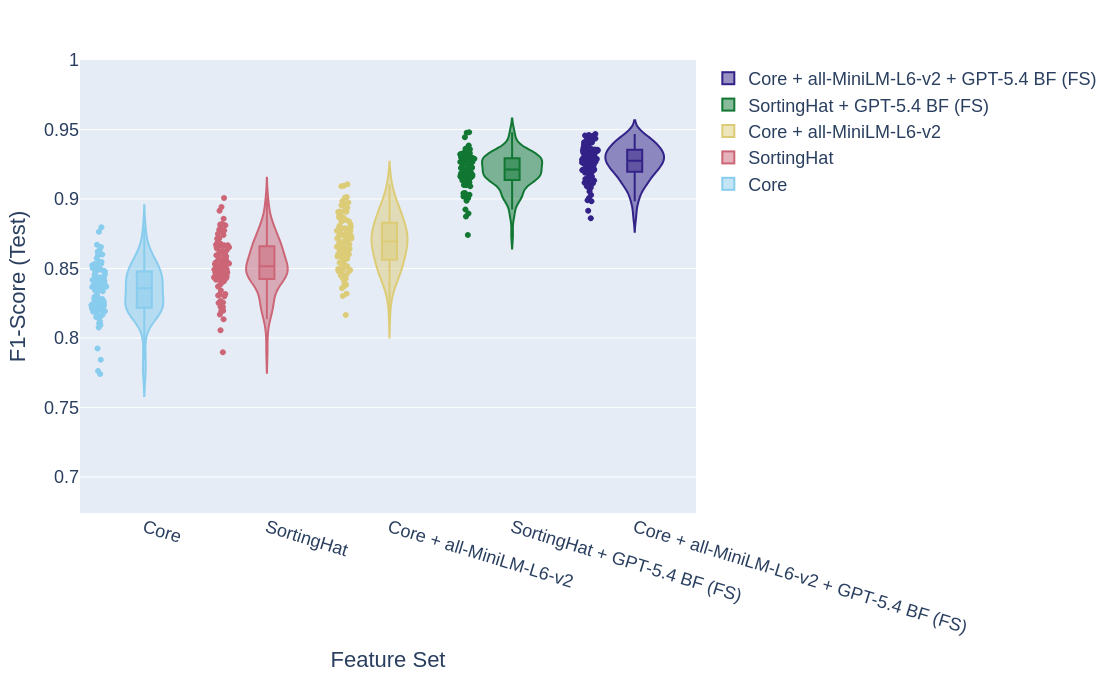

In [61]:
# ----------------------------
# Filter df
# ----------------------------
df = ag_results.loc[ag_results["Feature Set"].isin(fs)].copy()

# ----------------------------
# Ordering from median_df
# ----------------------------
ordered_features = [f for f in median_df["Feature Set"] if f in fs]
ordered_features = list(reversed(ordered_features))

# ----------------------------
# ABBREVIATION FUNCTION
# ----------------------------
def abbreviate_feature(name):
    name = name.replace("Core Features", "Core")
    name = name.replace("Binary Features", "BF")
    name = name.replace("all-MiniLM-L6-v2 embeddings", "all-MiniLM-L6-v2")
    name = name.replace("(Few-shot)", "(FS)")

    if "Core + Bi-grams" in name:
        name = name.replace("Core + Bi-grams", "SortingHat")
        
    return name

df["Feature Set Short"] = df["Feature Set"].apply(abbreviate_feature)
ordered_features_short = [abbreviate_feature(f) for f in ordered_features]

# ----------------------------
# VIOLIN PLOT
# ----------------------------
fig = px.violin(
    df,
    x="Feature Set Short",
    y="F1-Score (Test)",
    color="Feature Set Short",
    category_orders={"Feature Set Short": ordered_features_short},
    box=True,
    color_discrete_sequence=px.colors.qualitative.Safe,
    points="all",
)

# ----------------------------
# LEGEND SORT (DESC by mean F1)
# ----------------------------
legend_order = (
    df.groupby("Feature Set Short")["F1-Score (Test)"]
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

name_to_trace = {trace.name: trace for trace in fig.data}

fig.data = tuple(
    name_to_trace[name]
    for name in legend_order
    if name in name_to_trace
)

# ----------------------------
# LEGEND CLEANUP
# ----------------------------
for trace in fig.data:
    name = trace.name

    name = name.replace("Core Features", "Core")
    name = name.replace("Binary Features", "BF")
    name = name.replace("all-MiniLM-L6-v2 embeddings", "all-MiniLM-L6-v2")
    name = name.replace("(Few-shot)", "(FS)")

    if "Core + Bi-grams" in name:
        name = name.replace("Core + Bi-grams", "SortingHat")

    trace.name = name
    trace.legendgroup = name


# ----------------------------
# LAYOUT (FONT INCREASED HERE)
# ----------------------------
fig.update_layout(
    width=1300 * 0.85,
    height=800 * 0.85,

    legend=dict(
        font=dict(size=18),   # increased legend font
        title=None
    ),

    xaxis_title="Feature Set",
    yaxis_title="F1-Score (Test)",

    xaxis_title_font=dict(size=22),  # increased axis title font
    yaxis_title_font=dict(size=22),  # increased axis title font
)

# ----------------------------
# AXES FONT SIZE
# ----------------------------
fig.update_xaxes(
    tickangle=17,
    categoryorder="array",
    categoryarray=ordered_features_short,
    tickfont=dict(size=18)   # increased x-axis tick font
)

fig.update_yaxes(
    range=[df['F1-Score (Test)'].min() - 0.1, 1],
    tickfont=dict(size=18)   # increased y-axis tick font
)

# # Save figure as PDF
# fig.update_layout(
#     width=1000,
#     height=600,
#     margin=dict(l=40, r=40, t=60, b=60)  # important
# )

# fig.write_image(
#     "figures/violin_results_only_gpt.pdf",
#     format="pdf",
#     engine="kaleido",
#     scale=2  # avoid oversizing
# )

# ----------------------------
# SHOW
# ----------------------------
fig.show()

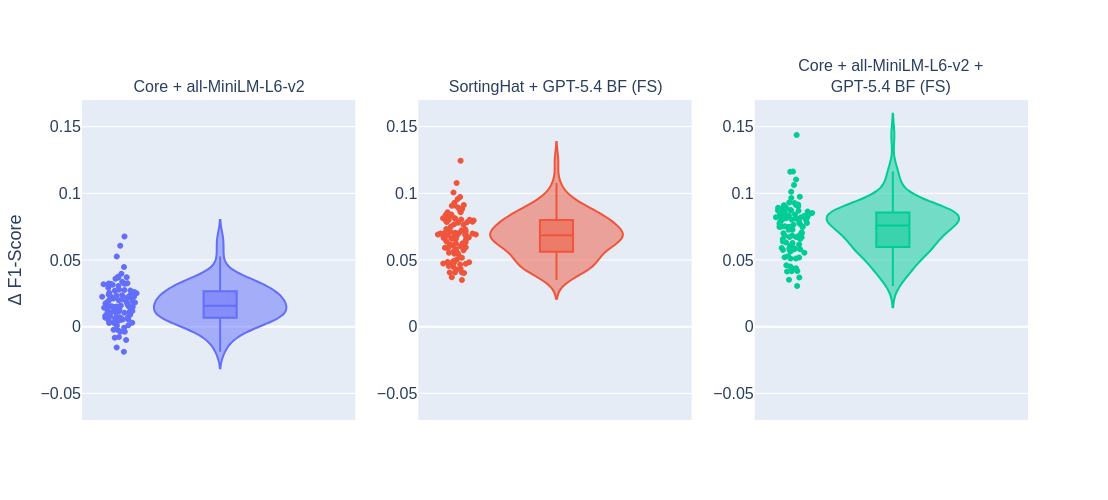

In [62]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ----------------------------
# Select datasets
# ----------------------------
df_base_bigram = ag_results.loc[
    ag_results['Feature Set'] == "Core Features + Bi-grams"
].reset_index(drop=True)

df_base_embedding = ag_results.loc[
    ag_results['Feature Set'] == "Core Features + all-MiniLM-L6-v2 embeddings"
].reset_index(drop=True)

df_base_bigram_gpt = ag_results.loc[
    ag_results['Feature Set'] == "Core Features + Bi-grams + GPT-5.4 Binary Features (Few-shot)"
].reset_index(drop=True)

df_base_embedding_gpt = ag_results.loc[
    ag_results['Feature Set'] == "Core Features + all-MiniLM-L6-v2 embeddings + GPT-5.4 Binary Features (Few-shot)"
].reset_index(drop=True)

# ----------------------------
# Compute differences
# ----------------------------
diff_bigram_gpt = df_base_bigram_gpt['F1-Score (Test)'].values - df_base_bigram['F1-Score (Test)'].values
diff_embedding = df_base_embedding['F1-Score (Test)'].values - df_base_bigram['F1-Score (Test)'].values
diff_bigram_to_embedding_gpt = df_base_embedding_gpt['F1-Score (Test)'].values - df_base_bigram['F1-Score (Test)'].values

# ----------------------------
# Create subplots (KEEP TITLES)
# ----------------------------
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=(
        "Core +" + " all-MiniLM-L6-v2",
        "SortingHat + " + "GPT-5.4 BF (FS)",
        "Core +" + " all-MiniLM-L6-v2 +" + "<br>" + "GPT-5.4 BF (FS)",
    )
)

# ----------------------------
# Add traces
# ----------------------------
fig.add_trace(
    go.Violin(y=diff_embedding, box_visible=True, points='all',
              name="Core+Embedding vs Core+Bi-gram"),
    row=1, col=1
)

fig.add_trace(
    go.Violin(y=diff_bigram_gpt, box_visible=True, points='all',
              name="Core+Bi-gram+GPT vs Core+Bi-gram"),
    row=1, col=2
)

fig.add_trace(
    go.Violin(y=diff_bigram_to_embedding_gpt, box_visible=True, points='all',
              name="Core+Embedding+GPT vs Core+Bi-gram"),
    row=1, col=3
)

# ----------------------------
# Layout
# ----------------------------
fig.update_layout(
    width=1000,
    height=500,
    showlegend=False,
    font=dict(size=16)
)

# ----------------------------
# Y-AXES (ONLY LEFT HAS LABEL)
# ----------------------------
fig.update_yaxes(
    title_text="Δ F1-Score",
    title_font=dict(size=18),
    row=1, col=1
)

fig.update_yaxes(
    title_text=None,
    row=1, col=2
)

fig.update_yaxes(
    title_text=None,
    row=1, col=3
)

# ----------------------------
# REMOVE X LABELS ON SUBPLOTS
# ----------------------------
for i in range(1, 4):
    fig.update_xaxes(showticklabels=False, row=1, col=i)

# ----------------------------
# UNIFORM Y-AXIS RANGE
# ----------------------------
for i in range(1, 4):
    fig.update_yaxes(row=1, col=i, range=[-0.07, 0.17])

# ----------------------------
# GLOBAL X-AXIS TITLE
# ----------------------------
fig.add_annotation(
    # text="Performance Difference Between Feature Set 1 and Feature Set 2<br>(Across 100 Splits)",
    text="",
    x=0.5,
    y=-0.15,
    xref="paper",
    yref="paper",
    showarrow=False,
    font=dict(size=24)
)

# # Save figure as PDF
# fig.update_layout(
#     width=1000,
#     height=450,
#     margin=dict(l=40, r=40, t=90, b=50)  # important
# )

# fig.write_image(
#     "figures/violin_differences.pdf",
#     format="pdf",
#     engine="kaleido",
#     scale=2  # avoid oversizing
# )

# ----------------------------
# SHOW
# ----------------------------
fig.show()

# Paired t-test

In [63]:
from scipy.stats import ttest_rel

In [64]:
fs = [
    'Core Features + Bi-grams',
    'Core Features + all-MiniLM-L6-v2 embeddings + GPT-5.4 Binary Features (Few-shot)'
]

In [65]:
a = ag_results.loc[ag_results['Feature Set'] == fs[0]]['F1-Score (Test)'].values
b = ag_results.loc[ag_results['Feature Set'] == fs[1]]['F1-Score (Test)'].values

In [66]:
ttest_rel(a, b)

TtestResult(statistic=-39.04612845178925, pvalue=6.048339157385166e-62, df=99)

## Class-wise

In [67]:
fs = [
    'Core Features + Bi-grams',
    'Core Features + all-MiniLM-L6-v2 embeddings + GPT-5.4 Binary Features (Few-shot)'
]

In [68]:
for c in class_map.values():
    cl = 'class_' + c + '_F1-Score'
    a = ag_results.loc[ag_results['Feature Set'] == fs[0]][cl].values
    b = ag_results.loc[ag_results['Feature Set'] == fs[1]][cl].values

    ttest = ttest_rel(a, b)

    print(f'class {c} ttest:\n{ttest}')
    print('-'*80)

class numeric ttest:
TtestResult(statistic=-20.001464605073732, pvalue=1.4976945721505353e-36, df=99)
--------------------------------------------------------------------------------
class categorical ttest:
TtestResult(statistic=-20.005425973565565, pvalue=1.474283090472221e-36, df=99)
--------------------------------------------------------------------------------
class datetime ttest:
TtestResult(statistic=-8.507890165224888, pvalue=1.9358885030449476e-13, df=99)
--------------------------------------------------------------------------------
class sentence ttest:
TtestResult(statistic=-15.53318265373594, pvalue=2.7163788139658106e-28, df=99)
--------------------------------------------------------------------------------
class url ttest:
TtestResult(statistic=-12.196293755532952, pvalue=1.9556419841028405e-21, df=99)
--------------------------------------------------------------------------------
class embedded-number ttest:
TtestResult(statistic=-13.85464242148789, pvalue=6.546369

# Calculate standard deviations on test data

In [69]:
f = "Core Features + all-MiniLM-L6-v2 embeddings + GPT-5.4 Binary Features (Few-shot)"

f1 = ag_results.loc[ag_results['Feature Set'] == f]['F1-Score (Test)'].values
prec = ag_results.loc[ag_results['Feature Set'] == f]['Precision (Test)'].values
rec = ag_results.loc[ag_results['Feature Set'] == f]['Recall (Test)'].values
acc = ag_results.loc[ag_results['Feature Set'] == f]['Accuracy (Test)'].values

In [70]:
print(f"{f}\n\n" + \
      f"F1-Score std: {round(np.std(f1), 3)}\n" + \
      f"Precision std: {round(np.std(prec), 3)}\n" + \
      f"Recall std: {round(np.std(rec), 3)}\n" + \
      f"Accuracy std: {round(np.std(acc), 3)}"
)

Core Features + all-MiniLM-L6-v2 embeddings + GPT-5.4 Binary Features (Few-shot)

F1-Score std: 0.013
Precision std: 0.013
Recall std: 0.015
Accuracy std: 0.014


# Averaged class specific metrics from 100 splits

In [71]:
stats = [
    'F1-Score (Dev)',
    'Precision (Dev)',
    'Recall (Dev)',
    'Accuracy (Dev)',
    'F1-Score (Test)',
    'Precision (Test)',
    'Recall (Test)',
    'Accuracy (Test)',
    'class_numeric_F1-Score',
    'class_numeric_Precision',
    'class_numeric_Recall',
    'class_numeric_Accuracy',
    'class_categorical_F1-Score',
    'class_categorical_Precision',
    'class_categorical_Recall',
    'class_categorical_Accuracy',
    'class_sentence_F1-Score',
    'class_sentence_Precision',
    'class_sentence_Recall',
    'class_sentence_Accuracy',
    'class_url_F1-Score',
    'class_url_Precision',
    'class_url_Recall',
    'class_url_Accuracy',
    'class_list_F1-Score',
    'class_list_Precision',
    'class_list_Recall',
    'class_list_Accuracy',
    'class_embedded-number_F1-Score',
    'class_embedded-number_Precision',
    'class_embedded-number_Recall',
    'class_embedded-number_Accuracy',
    'class_datetime_F1-Score',
    'class_datetime_Precision',
    'class_datetime_Recall',
    'class_datetime_Accuracy',
    'class_not-generalizable_F1-Score',
    'class_not-generalizable_Precision',
    'class_not-generalizable_Recall',
    'class_not-generalizable_Accuracy',
    'class_context-specific_F1-Score',
    'class_context-specific_Precision',
    'class_context-specific_Recall',
    'class_context-specific_Accuracy'
]

In [72]:
median_class_specific = ag_results.groupby("Feature Set")[stats[8:]].median().round(3).reset_index()

In [73]:
fs = [
    'Core Features + Bi-grams', # baseline
    median_df['Feature Set'][0] # best feature set
]

In [74]:
for f in fs:
    print(f"%%%%%%%%%% Feature Set: {f} %%%%%%%%%%\n")
    for c in class_map.values():
        print(f"### Class {c} ###\n")
        class_metrics = [f for f in list(median_class_specific.columns) if c in str(f).lower()]
        for m in class_metrics:
            print(f'{m.replace("class_", "").replace(c+"_", "", )}: {median_class_specific.loc[median_class_specific["Feature Set"]==f][m].values[0]}')
        print('\n')
    print('///////////////////////////////////////////////////////////////\n')

%%%%%%%%%% Feature Set: Core Features + Bi-grams %%%%%%%%%%

### Class numeric ###

F1-Score: 0.93
Precision: 0.93
Recall: 0.95
Accuracy: 0.95


### Class categorical ###

F1-Score: 0.9
Precision: 0.89
Recall: 0.925
Accuracy: 0.95


### Class datetime ###

F1-Score: 0.99
Precision: 0.99
Recall: 0.99
Accuracy: 1.0


### Class sentence ###

F1-Score: 0.91
Precision: 0.91
Recall: 0.91
Accuracy: 0.99


### Class url ###

F1-Score: 0.96
Precision: 1.0
Recall: 0.96
Accuracy: 1.0


### Class embedded-number ###

F1-Score: 0.945
Precision: 0.96
Recall: 0.94
Accuracy: 0.99


### Class list ###

F1-Score: 0.615
Precision: 0.7
Recall: 0.53
Accuracy: 0.99


### Class not-generalizable ###

F1-Score: 0.93
Precision: 0.93
Recall: 0.93
Accuracy: 0.99


### Class context-specific ###

F1-Score: 0.55
Precision: 0.64
Recall: 0.48
Accuracy: 0.95


///////////////////////////////////////////////////////////////

%%%%%%%%%% Feature Set: Core Features + all-MiniLM-L6-v2 embeddings + GPT-5.4 Binary Features 

In [75]:
for f in fs:
    print(f"%%%%%%% Feature Set: {f} %%%%%%%\n")
    macro_avg = []
    for c in class_map.values():
        class_metrics = [f for f in list(median_class_specific.columns) if c in str(f).lower()]
        for m in class_metrics:
            if m.replace("class_", "").replace(c+"_", "", ) == 'F1-Score':
                macro_avg.append(median_class_specific.loc[median_class_specific["Feature Set"]==f][m].values[0])
    print(f'Macro avg. F1-Score across 9 Binary Features: {round(np.mean(macro_avg), 3)}\n\n\n')

%%%%%%% Feature Set: Core Features + Bi-grams %%%%%%%

Macro avg. F1-Score across 9 Binary Features: 0.859



%%%%%%% Feature Set: Core Features + all-MiniLM-L6-v2 embeddings + GPT-5.4 Binary Features (Few-shot) %%%%%%%

Macro avg. F1-Score across 9 Binary Features: 0.935





# Best Hyperparameters

In [79]:
from collections import Counter
import pandas as pd

def parse_value(v):
    if isinstance(v, str):
        try:
            return int(v)
        except ValueError:
            try:
                return float(v)
            except ValueError:
                pass
    return v

param_counts = Counter(
    (k, parse_value(v))
    for model_dict in ag_results['Model']
    for k, v in model_dict.get("Parameters", {}).items()
)

best_hyperparams_df = (
    pd.DataFrame(
        [(k, v, c) for (k, v), c in param_counts.items()],
        columns=["Parameter", "Value", "Count"]
    )
    .sort_values(["Parameter", "Count"], ascending=[True, False])
    .reset_index(drop=True)
)

best_hyperparams_df

,Parameter,Value,Count
0,booster,gbtree,500
1,learning_rate,0.1,500
2,n_estimators,10000,500
3,n_jobs,-1,500
4,num_class,9,500
5,objective,multi:softprob,500
6,proc.max_category_levels,100,500


# Confusion Matrix of best feature set vs baseline from best dev splits

In [80]:
fs = [
    'Core Features + Bi-grams', # baseline
    median_df['Feature Set'][0] # best feature set
]

In [81]:
seed_baseline = 14085 # best median seed baseline
seed_best_model = 13569 # best median seed best model

print(f'Best seed for {fs[0]}: {seed_baseline}')
print(f'Best seed for {fs[1]}: {seed_best_model}')

Best seed for Core Features + Bi-grams: 14085
Best seed for Core Features + all-MiniLM-L6-v2 embeddings + GPT-5.4 Binary Features (Few-shot): 13569


In [82]:
best_model = median_df.loc[0]
best_params = (
    best_hyperparams_df
    .sort_values('Count', ascending=False)      # most frequent first
    .drop_duplicates(subset='Parameter')        # keep only the top value per parameter
    .set_index('Parameter')['Value']            # set Parameter as key
    .to_dict()                                  # convert to dict
)


		###### Feature Set: Core Features + Bi-grams ######



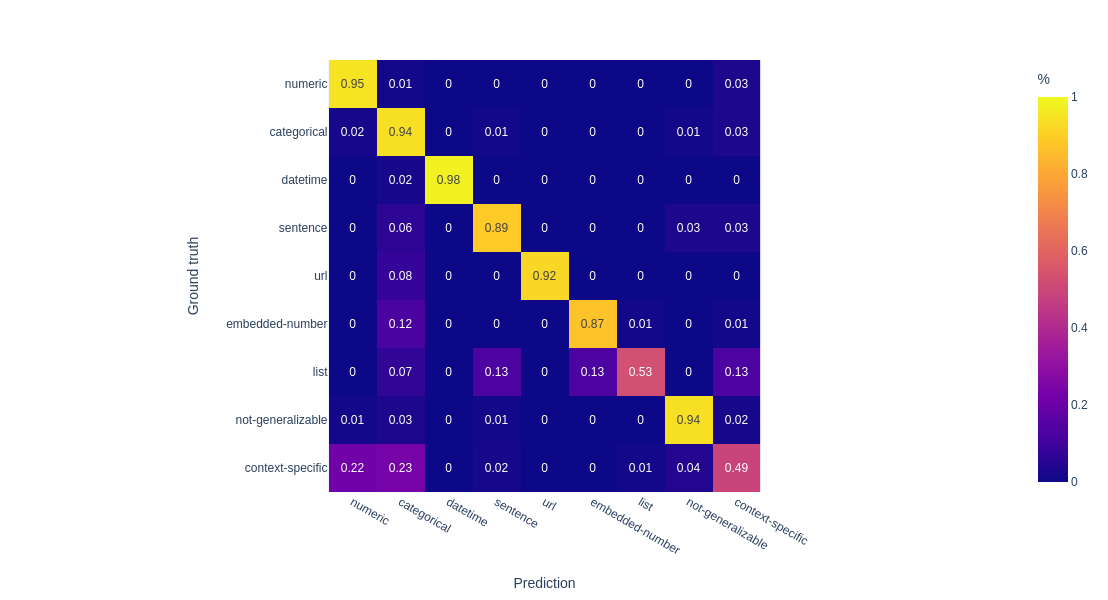

######### General model performance #########

F1-Score: 0.857
Precision: 0.889
Recall: 0.834
Accuracy: 0.905

######### Binarization Metrics #########

## Class: numeric ##

F1-Score: 0.94
Precision: 0.92
Recall: 0.95
Accuracy: 0.97

////////////////////////////////////////

## Class: categorical ##

F1-Score: 0.92
Precision: 0.9
Recall: 0.94
Accuracy: 0.94

////////////////////////////////////////

## Class: datetime ##

F1-Score: 0.99
Precision: 1.0
Recall: 0.98
Accuracy: 1.0

////////////////////////////////////////

## Class: sentence ##

F1-Score: 0.89
Precision: 0.89
Recall: 0.89
Accuracy: 0.99

////////////////////////////////////////

## Class: url ##

F1-Score: 0.96
Precision: 1.0
Recall: 0.92
Accuracy: 1.0

////////////////////////////////////////

## Class: embedded-number ##

F1-Score: 0.91
Precision: 0.97
Recall: 0.87
Accuracy: 0.99

////////////////////////////////////////

## Class: list ##

F1-Score: 0.64
Precision: 0.8
Recall: 0.53
Accuracy: 0.99

////////////////////

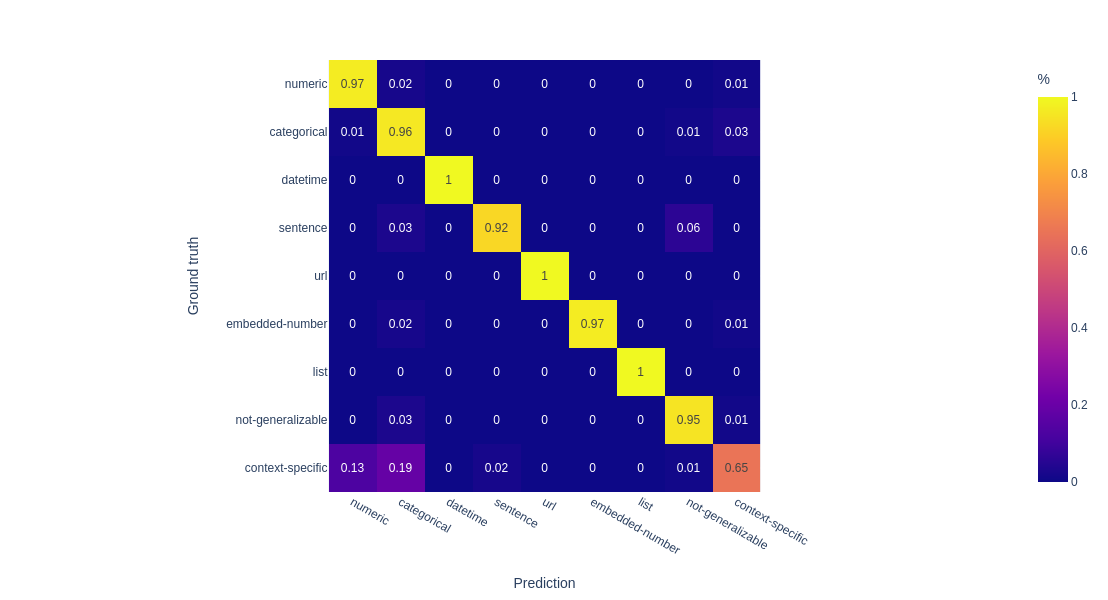

######### General model performance #########

F1-Score: 0.937
Precision: 0.941
Recall: 0.934
Accuracy: 0.948

######### Binarization Metrics #########

## Class: numeric ##

F1-Score: 0.97
Precision: 0.96
Recall: 0.97
Accuracy: 0.98

////////////////////////////////////////

## Class: categorical ##

F1-Score: 0.95
Precision: 0.94
Recall: 0.96
Accuracy: 0.96

////////////////////////////////////////

## Class: datetime ##

F1-Score: 1.0
Precision: 1.0
Recall: 1.0
Accuracy: 1.0

////////////////////////////////////////

## Class: sentence ##

F1-Score: 0.93
Precision: 0.94
Recall: 0.92
Accuracy: 0.99

////////////////////////////////////////

## Class: url ##

F1-Score: 1.0
Precision: 1.0
Recall: 1.0
Accuracy: 1.0

////////////////////////////////////////

## Class: embedded-number ##

F1-Score: 0.99
Precision: 1.0
Recall: 0.97
Accuracy: 1.0

////////////////////////////////////////

## Class: list ##

F1-Score: 0.97
Precision: 0.94
Recall: 1.0
Accuracy: 1.0

//////////////////////////

In [83]:
for x in fs:
    
    feature_set_data = featurized_data.copy()

    model = TabularPredictor(label="y_act",
                             problem_type='multiclass',
                             eval_metric='f1_macro',
                             path='results/best_model',
                             verbosity=0)

    if 'embedding' in x.lower():
        fold = splitting.create_split(all_datasets, test_size=0.2, target_col='y_act', group_col='Record_id', random_state=seed_best_model)
        train = feature_set_data.iloc[fold["train"]].reset_index(drop=True)
        test = feature_set_data.iloc[fold["test"]].reset_index(drop=True)
        
        sentenceTF_vc = feature_extraction.SentenceTFVectorizer()
        feature_set_data = sentenceTF_vc.transform(featurized_data)
        
        features_to_learn = feature_sets[x]['features'] + ['SentenceTF_embedding_dim_'+ str(i) for i in range(384)]
  

    if 'bi-gram' in x.lower():
        fold = splitting.create_split(all_datasets, test_size=0.2, target_col='y_act', group_col='Record_id', random_state=seed_baseline)
        train = feature_set_data.iloc[fold["train"]].reset_index(drop=True)
        test = feature_set_data.iloc[fold["test"]].reset_index(drop=True)
        
        bigram_vc= feature_extraction.BigramVectorizer()
        bigram_vc.fit(train, normalize=False, top_k=1500)
    
        train = bigram_vc.transform(train.filter(feature_sets[x]['features'] + ['Attribute_name', 'y_act']))
        test = bigram_vc.transform(test.filter(feature_sets[x]['features'] + ['Attribute_name', 'y_act']))
        
        features_to_learn = feature_sets[x]['features'] + [str(b) for b in list(bigram_vc.bigrams.values())]

        
    
    # Training
    X_train = train.filter(features_to_learn)
    y_train = train["y_act"]
    # some columns are int, make all strings to escape error from model.fit
    X_train.columns = X_train.columns.astype(str)
    train_data = X_train.copy()
    train_data["y_act"] = y_train
    
    # Predicting
    X_test = test.filter(features_to_learn)
    y_test = test["y_act"]
    # some columns are int, make all strings to escape error from model.fit
    X_test.columns = X_test.columns.astype(str)
    test_data = X_test.copy()
    test_data["y_act"] = y_test


    # Model
    model.fit(
        train_data=train_data,
        feature_generator=None,  # disables preprocessing
        hyperparameters={'XGB': best_params},
        excluded_model_types=[],  # ensures no other models are trained
        presets='best_quality',
        time_limit=600,
        num_stack_levels=0,
        num_bag_folds=0
    )

    y_pred = model.predict(test_data)

    # convert classes back to strings
    y_test = le.inverse_transform(y_test)
    y_pred = le.inverse_transform(y_pred)

    print(f'\n\t\t###### Feature Set: {x} ######\n')

    if x == fs[0]:
        # metrics.plot_heatmap(y_test, y_pred, class_map, decimal_places=2, save_path='figures/CM_RerunBaseline.pdf')
        metrics.plot_heatmap(y_test, y_pred, class_map, decimal_places=2)
    else:
        # metrics.plot_heatmap(y_test, y_pred, class_map, decimal_places=2, save_path='figures/CM_BestModel.pdf')
        metrics.plot_heatmap(y_test, y_pred, class_map, decimal_places=2)

    # metrics.plot_heatmap(y_test, y_pred, class_map, decimal_places=2)    
    metrics.model_performance(y_test, y_pred, class_map, decimal_places=3, class_average="macro")
    metrics.binary_metrics(y_test, y_pred, class_map, decimal_places=2)

    print('\n')